# 09 - Bonus: Consumo de API Externa de Conversión de Monedas

## Objetivo del Proyecto

Este notebook demuestra:
- **Consumo de una API externa**: Llamadas HTTP a servicios REST
- **Uso de datos actualizados**: Tasas de cambio en tiempo real
- **Procesamiento de datos en Python**: Manipulación de JSON y datos
- **Visualización con gráficos**: Uso de matplotlib para representar datos

Vamos a consumir la API pública de **Frankfurter** (frankfurter.app) para obtener tasas de cambio de monedas y crear visualizaciones. Esta API es completamente gratuita y no requiere API key.

## 1. Importar Librerías Necesarias

Vamos a importar las librerías que necesitamos:
- `requests`: Para hacer peticiones HTTP a la API
- `matplotlib.pyplot`: Para crear gráficos
- `datetime` y `timedelta`: Para manejar fechas en datos históricos

In [20]:
# Importar librerías necesarias
import requests
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import json

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Obtener Tasas de Cambio Actuales

Vamos a hacer una petición GET a la API para obtener las tasas de cambio actuales usando USD como moneda base.

**Endpoint**: `https://api.frankfurter.app/latest?from=USD`

Este endpoint nos devuelve las tasas de cambio de USD a otras monedas en formato JSON.

In [21]:
# Hacer petición a la API para obtener tasas actuales
url_latest = "https://api.frankfurter.app/latest"
parametros = {
    "from": "USD",  # Moneda base: Dólar estadounidense
    "to": "EUR,BRL,GBP,JPY"  # Monedas que nos interesan
}

print(" Realizando petición a la API...")
response = requests.get(url_latest, params=parametros)

# Verificar que la petición fue exitosa
if response.status_code == 200:
    print("✓ Petición exitosa (Status Code: 200)")
    datos = response.json()
    print("\n📊 Respuesta de la API:")
    print(json.dumps(datos, indent=2))
else:
    print(f"❌ Error en la petición: {response.status_code}")

 Realizando petición a la API...
✓ Petición exitosa (Status Code: 200)

📊 Respuesta de la API:
{
  "amount": 1.0,
  "base": "USD",
  "date": "2026-03-23",
  "rates": {
    "BRL": 5.2595,
    "EUR": 0.86237,
    "GBP": 0.74526,
    "JPY": 158.55
  }
}


## 3. Extraer y Mostrar las Tasas de Cambio

Vamos a extraer las tasas de cambio del JSON y mostrarlas de forma clara.

In [22]:
# Extraer las tasas de cambio del JSON
tasas = datos['rates']

print("💱 TASAS DE CAMBIO ACTUALES (Base: 1 USD)")
print("=" * 50)
for moneda, tasa in tasas.items():
    print(f"1 USD = {tasa:.2f} {moneda}")
print("=" * 50)

💱 TASAS DE CAMBIO ACTUALES (Base: 1 USD)
1 USD = 5.26 BRL
1 USD = 0.86 EUR
1 USD = 0.75 GBP
1 USD = 158.55 JPY


## 4. Realizar Conversiones de Moneda

Ahora vamos a convertir una cantidad específica de USD a otras monedas usando las tasas obtenidas.

In [23]:
# Función simple para convertir moneda
def convertir_moneda(cantidad_usd, moneda_destino, tasas):
    """
    Convierte una cantidad en USD a otra moneda
    
    Parámetros:
    - cantidad_usd: Cantidad en dólares a convertir
    - moneda_destino: Código de la moneda destino (ej: 'ARS', 'EUR')
    - tasas: Diccionario con las tasas de cambio
    
    Retorna:
    - Cantidad convertida
    """
    tasa = tasas[moneda_destino]
    return cantidad_usd * tasa

# Realizar conversiones de ejemplo
cantidad = 100  # 100 dólares

print(f"\n💰 CONVERSIÓN DE {cantidad} USD A OTRAS MONEDAS")
print("=" * 50)

# Convertir solo a las monedas disponibles en la respuesta de la API
nombres_monedas = {
    'EUR': 'Euro',
    'BRL': 'Real Brasileño',
}

for codigo, nombre in nombres_monedas.items():
    if codigo in tasas:
        valor = convertir_moneda(cantidad, codigo, tasas)
        print(f"{cantidad} USD = {valor:.2f} {codigo} ({nombre})")
    else:
        print(f"⚠️ {codigo} ({nombre}) no disponible en la respuesta de la API")

print("=" * 50)


💰 CONVERSIÓN DE 100 USD A OTRAS MONEDAS
100 USD = 86.24 EUR (Euro)
100 USD = 525.95 BRL (Real Brasileño)


## 5. Visualización: Gráfico de Barras

Vamos a crear un gráfico de barras que muestre visualmente el valor de 1 USD en diferentes monedas.

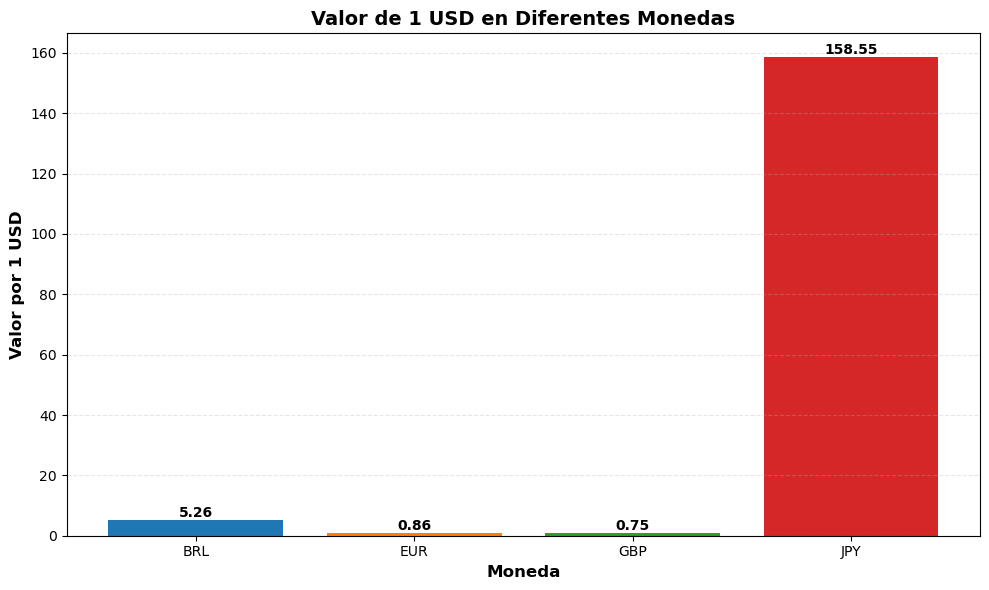

✓ Gráfico de barras generado y guardado en outputs/figures/


In [24]:
# Preparar datos para el gráfico
monedas = list(tasas.keys())
valores = list(tasas.values())

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(monedas, valores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Agregar etiquetas y título
plt.xlabel('Moneda', fontsize=12, fontweight='bold')
plt.ylabel('Valor por 1 USD', fontsize=12, fontweight='bold')
plt.title('Valor de 1 USD en Diferentes Monedas', fontsize=14, fontweight='bold')

# Agregar los valores encima de cada barra
for i, valor in enumerate(valores):
    plt.text(i, valor, f'{valor:.2f}', ha='center', va='bottom', fontweight='bold')

# Agregar cuadrícula para mejor lectura
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Guardar el gráfico
plt.tight_layout()
plt.savefig('outputs/figures/09_api_conversion_monedas_barras.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico de barras generado y guardado en outputs/figures/")

## 6. Obtener Datos Históricos (Serie de Tiempo)

Ahora vamos a obtener datos históricos del tipo de cambio USD a EUR de los últimos 30 días usando el formato de rango de fechas.

**Endpoint**: `https://api.frankfurter.app/START_DATE..END_DATE`

In [25]:
# Calcular fechas: últimos 30 días
fecha_fin = datetime.now()
fecha_inicio = fecha_fin - timedelta(days=30)

# Formatear fechas en formato YYYY-MM-DD
fecha_inicio_str = fecha_inicio.strftime('%Y-%m-%d')
fecha_fin_str = fecha_fin.strftime('%Y-%m-%d')

print(f"📅 Obteniendo datos históricos desde {fecha_inicio_str} hasta {fecha_fin_str}")

# Hacer petición al endpoint de rango de fechas
url_timeseries = f"https://api.frankfurter.app/{fecha_inicio_str}..{fecha_fin_str}"
parametros_historicos = {
    "from": "USD",
    "to": "EUR"
}

print("📡 Realizando petición a la API...")
response_historico = requests.get(url_timeseries, params=parametros_historicos)

if response_historico.status_code == 200:
    print("✓ Datos históricos obtenidos exitosamente")
    datos_historicos = response_historico.json()
    
    # Extraer las tasas por fecha
    tasas_historicas = datos_historicos['rates']
    
    print(f"\n📊 Se obtuvieron {len(tasas_historicas)} días de datos")
else:
    print(f"❌ Error al obtener datos históricos: {response_historico.status_code}")

📅 Obteniendo datos históricos desde 2026-02-21 hasta 2026-03-23
📡 Realizando petición a la API...
✓ Datos históricos obtenidos exitosamente

📊 Se obtuvieron 22 días de datos


## 7. Visualización: Gráfico de Línea (Evolución Temporal)

Vamos a crear un gráfico de línea que muestre la evolución del tipo de cambio USD a EUR durante los últimos 30 días.

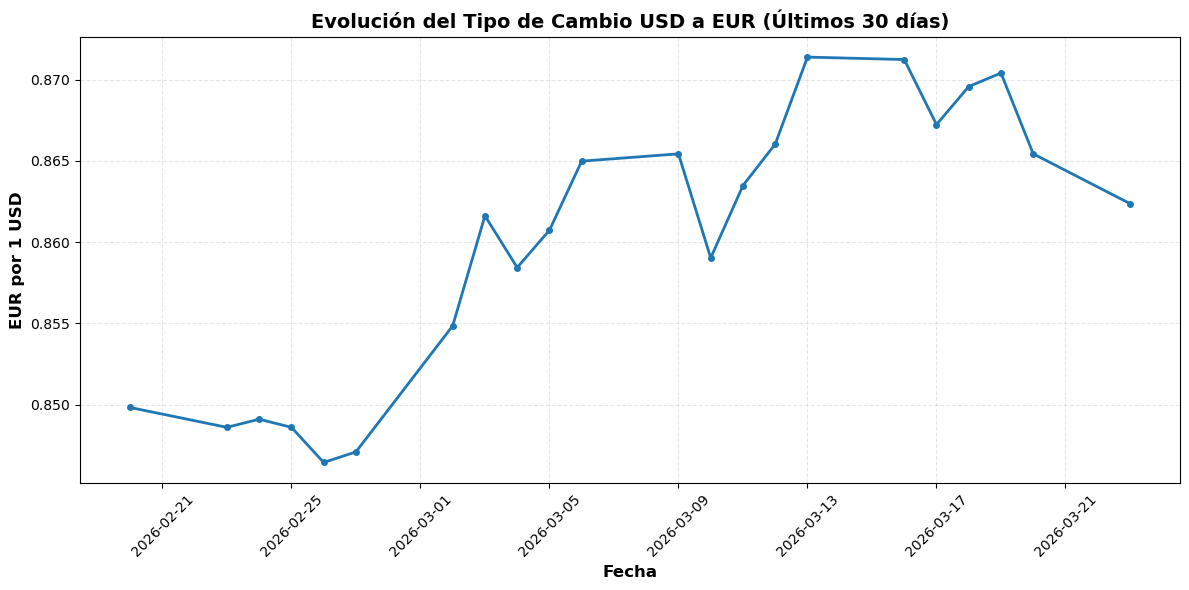


📈 ESTADÍSTICAS DEL PERÍODO
Tasa mínima: 0.8465 EUR por USD
Tasa máxima: 0.8714 EUR por USD
Tasa promedio: 0.8601 EUR por USD
Variación: 0.0249 EUR


In [27]:
# Preparar datos para el gráfico de línea
fechas = []
tasas_ars = []

for fecha, valores in sorted(tasas_historicas.items()):
    fechas.append(datetime.strptime(fecha, '%Y-%m-%d'))
    tasas_ars.append(valores['EUR'])

# Crear el gráfico de línea
plt.figure(figsize=(12, 6))
plt.plot(fechas, tasas_ars, marker='o', linewidth=2, markersize=4, color='#1f77b4')

# Agregar etiquetas y título
plt.xlabel('Fecha', fontsize=12, fontweight='bold')
plt.ylabel('EUR por 1 USD', fontsize=12, fontweight='bold')
plt.title('Evolución del Tipo de Cambio USD a EUR (Últimos 30 días)', fontsize=14, fontweight='bold')

# Rotar las etiquetas del eje X para mejor legibilidad
plt.xticks(rotation=45)

# Agregar cuadrícula
plt.grid(True, alpha=0.3, linestyle='--')

# Guardar y mostrar el gráfico
plt.tight_layout()
plt.savefig('outputs/figures/09_api_evolucion_usd_eur.png', dpi=300, bbox_inches='tight')
plt.show()

# Mostrar estadísticas
print("\n📈 ESTADÍSTICAS DEL PERÍODO")
print("=" * 50)
print(f"Tasa mínima: {min(tasas_ars):.4f} EUR por USD")
print(f"Tasa máxima: {max(tasas_ars):.4f} EUR por USD")
print(f"Tasa promedio: {sum(tasas_ars)/len(tasas_ars):.4f} EUR por USD")
print(f"Variación: {max(tasas_ars) - min(tasas_ars):.4f} EUR")
print("=" * 50)

## 8. Resumen y Conclusiones

✅ **Logros de este notebook:**

1. **Consumo de API Externa**: Hicimos peticiones HTTP exitosas a la API de Frankfurter
2. **Procesamiento de JSON**: Extrajimos y manipulamos datos en formato JSON
3. **Conversiones de Moneda**: Convertimos USD a múltiples monedas.
4. **Visualización con Barras**: Comparamos visualmente las tasas de cambio actuales
5. **Datos Históricos**: Obtuvimos series de tiempo de los últimos 30 días
6. **Visualización con Línea**: Graficamos la evolución temporal del USD/EUR

---

**API Utilizada:** [Frankfurter](https://frankfurter.app) - API completamente gratuita, sin API key, basada en datos del Banco Central Europeo

**Tecnologías:** Python, requests, matplotlib

**Fecha de creación:** Marzo 2026